*   Doğal Dil İşleme (NLP)
*   Konuşma Tanıma
*   Zaman Serisi Tahmini
*   Müzik ve Metin Üretimi
*   Video İşleme
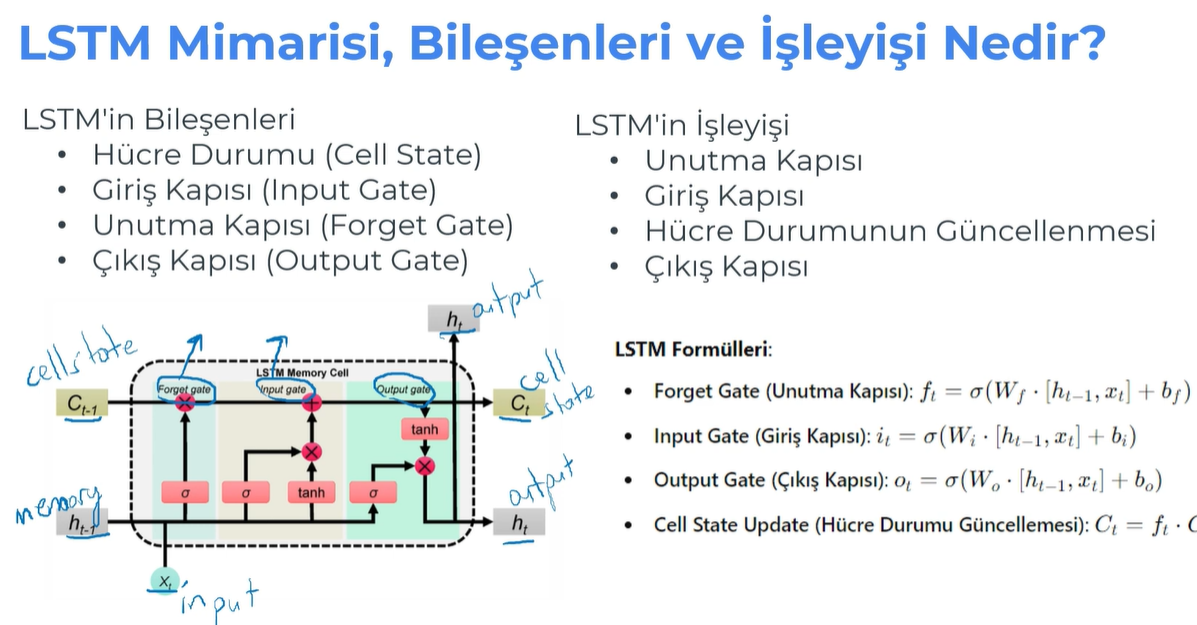

In [23]:
!pip install tensorflow keras

In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [25]:
#eğitim veri setinin oluşturulması
texts = [
    "Bugün hava çok güzel, dışarıda yürüyüş yapmayı düşünüyorum.",
    "Kitap okumak beni gerçekten mutlu ediyor.",
    "Sabahları kahve içmeden güne başlayamıyorum.",
    "Trafik o kadar sıkışıktı ki işe zar zor yetiştim.",
    "Yeni aldığım çikolatalı pastanın tadı harikaydı.",
    "Akşam yemeğinden sonra biraz film izlemek istiyorum.",
    "Bugün işte çok yoruldum, hemen uyumak istiyorum.",
    "Hafta sonu arkadaşlarla pikniğe gitmek için plan yaptık.",
    "Evi temizlemek sandığımdan daha uzun sürdü.",
    "Marketten almam gerekenleri bir listeye yazdım.",
    "Bu şarkı bana eski günleri hatırlatıyor.",
    "Sınav sonuçları açıklandığında çok heyecanlandım.",
    "Güneşli havalarda balkonda oturup çay içmeyi seviyorum.",
    "Telefonumun şarjı bitmek üzere, prize takmam lazım.",
    "Dün gece izlediğim dizi gerçekten çok sürükleyiciydi.",
    "Spor yapmak kendimi daha zinde hissetmemi sağlıyor.",
    "Yemek yaparken arka planda müzik dinlemeye bayılırım.",
    "Kışın kar yağdığında pencereden izlemek çok huzur verici.",
    "Bugün ofiste toplantılar arka arkaya geldi.",
    "Uzun zamandır görmediğim bir arkadaşımla karşılaştım.",
    "Yeni bir dil öğrenmek için kursa yazılmayı düşünüyorum.",
    "Çiçekleri sulamayı unuttuğum için biraz solmuşlar.",
    "Bilgisayarımın ekranı aniden kapanınca panikledim.",
    "Evcil hayvanımla oynamak tüm stresimi alıyor.",
    "Yarınki sunum için hazırlık yapmam gerekiyor.",
    "Otobüsü kaçırdığım için bir sonraki durağa kadar yürüdüm.",
    "Bugün canım sadece evde oturup dinlenmek istiyor.",
    "Alışveriş merkezinde indirim olduğunu duyunca hemen gittim.",
    "Yağmurlu günlerde battaniyenin altına girip kitap okumak en iyisi.",
    "Yeni denediğim yemek tarifi beklediğimden daha iyi oldu.",
    "Saçlarımı kestirmek için kuaförden randevu aldım.",
    "Masanın üzerindeki dağınıklığı toplamak için zaman ayırdım.",
    "Bu aralar çok fazla tatlı tüketiyorum, dikkat etmeliyim.",
    "Gece uyumadan önce mutlaka bir bardak su içerim.",
    "Haberleri okurken dünyada neler olup bittiğini takip ediyorum.",
    "Sabah koşusu yapmak gün boyu enerjik kalmamı sağlıyor.",
    "Evdeki internet bağlantısı bugün çok yavaş.",
    "Çocukken oynadığım oyunları görünce gülümsedim.",
    "Kahvaltıda taze simit ve peynir yemeye bayılırım.",
    "Kargom beklediğimden çok daha erken geldi.",
    "Fırından gelen taze ekmek kokusu beni her zaman acıktırır.",
    "Bugün hava biraz serin, yanıma ceket alsam iyi olacak.",
    "İzlediğim belgesel doğa hakkında ilginç bilgiler veriyordu.",
    "Buzdolabında hiçbir şey kalmamış, alışverişe çıkmalıyım.",
    "Günün yorgunluğunu atmak için sıcak bir duş alacağım.",
    "Arkadaşımın doğum günü için ona güzel bir hediye seçtim.",
    "Gözlüklerimi nereye koyduğumu bir türlü bulamıyorum.",
    "Eski fotoğraflara bakarken zamanın ne kadar hızlı geçtiğini anladım.",
    "Cüzdanımı evde unuttuğumu kasaya geldiğimde fark ettim.",
    "Gökyüzündeki bulutlar pamuk şekerine benziyor.",
    "Yeni taşındığımız mahalle oldukça sessiz ve sakin.",
    "Dişçiye gitmek beni her zaman biraz tedirgin eder.",
    "Radyoda çalan şarkıya gayri ihtiyari eşlik ettim.",
    "Meyve tabağı hazırlayıp televizyonun karşısına geçtim.",
    "Çalar saat çalmadan beş dakika önce uyandım.",
    "Arabayı park edecek yer bulmak için üç tur attım.",
    "Çayın yanına ikram etmek için kek pişirdim.",
    "Bugün hiç keyfim yok, sadece yalnız kalmak istiyorum.",
    "Sokak kedilerine mama vermek için sokağa indim.",
    "Yaz tatili için şimdiden plan yapmaya başladık.",
    "Gömleğimin düğmesi koptuğu için onu dikmem gerekti.",
    "Dolaptaki kıyafetlerimi yazlık ve kışlık olarak ayırdım.",
    "Bugün hiç ummadığım bir anda güzel bir haber aldım.",
    "Kulağımda kulaklık varken dış dünyadan tamamen kopuyorum.",
    "Bahçedeki ağaçların yaprakları dökülmeye başlamış.",
    "Çalışırken masamda her zaman bir bardak kahve bulunur.",
    "Yeni aldığım ayakkabı ayağımı biraz sıktı.",
    "Tiyatro oyunu o kadar komikti ki gülmekten karnıma ağrılar girdi.",
    "Deniz kenarında yürümek bana her zaman iyi gelmiştir.",
    "Faturaları ödemek için bankanın uygulamasını açtım.",
    "Şehir dışından misafirlerim geleceği için evi toparlıyorum.",
    "Sokakta yürürken aniden yağmur bastırdı ve sırılsıklam oldum.",
    "Sosyal medyada çok fazla zaman harcadığımı fark ettim.",
    "Bugün gökyüzü o kadar berrak ki yıldızlar çok net görünüyor.",
    "Kendi başıma sinemaya gitmekten büyük keyif alıyorum.",
    "Patlamış mısır yaparken ocağın altını fazla açmışım, biraz yandı.",
    "Bu restorandaki garsonlar gerçekten çok ilgili ve kibar.",
    "Kardeşimle video oyunları oynarken zamanın nasıl geçtiğini anlamıyoruz.",
    "Sabah kalkar kalkmaz ilk işim pencereleri açıp odayı havalandırmak olur.",
    "Toplu taşımada kitap okumak yolculuğu kısaltıyor.",
    "Çiçekçiden aldığım papatyalar odaya harika bir koku yaydı.",
    "İnternetten sipariş ettiğim kitaplar nihayet elime ulaştı.",
    "Bugün mutfakta yeni bir makarna sosu deneyeceğim.",
    "Ekrana çok uzun süre baktığım için gözlerim kurumaya başladı.",
    "Bisiklet sürmek çocukluk yıllarıma dönmüşüm gibi hissettiriyor.",
    "Farklı kültürlerin yemeklerini tatmak beni çok heyecanlandırır.",
    "Yolda yürürken ayağım takıldı ama düşmeden toparlandım.",
    "Bugün nedensiz bir şekilde kendimi çok pozitif hissediyorum.",
    "Alarmı erteleyip birkaç dakika daha uyumanın tadı paha biçilemez.",
    "Evdeki bitkilerim için yeni saksılar almam gerekiyor.",
    "Güneş gözlüklerimi arabada unuttuğum için gözlerim kamaştı.",
    "Bir fincan bitki çayı içmek boğazıma çok iyi geldi.",
    "Çocukların parktaki neşeli çığlıkları mahalleye enerji katıyor.",
    "Ceketimin cebinde unuttuğum bir miktar para buldum, çok sevindim.",
    "Bugün erken yatıp yarın sabah güne erken başlamayı hedefliyorum.",
    "Duvardaki saatin tiktakları gecenin sessizliğinde çok net duyuluyor.",
    "Yeni bir yazar keşfettim ve tüm kitaplarını okumak istiyorum.",
    "Egzersiz yaptıktan sonra esneme hareketlerini unutmamaya çalışıyorum.",
    "Her sabah aynı saatte aynı kuşu penceremin önünde görüyorum.",
    "Yarın haftanın son iş günü olduğu için içimde garip bir sevinç var."
]

In [26]:
#pre processing
#tokenizer -> her kelimeyi benzersiz bir index atar
tokenizer=Tokenizer()
tokenizer.fit_on_texts(texts)
total_words=len(tokenizer.word_index) + 1 #toplam kelime sayısı

#n gram dizileri oluştur
#örn: "bugün hava çok güzel" -> input:"bugün hava" -> hedef:"çok"
#input:"hava çok" -> hedef:"güzel"
input_sequences=[]
for text in texts:
  token_list=tokenizer.texts_to_sequences([text])[0] #cümleyi sayısal indexlere çevir
  for i in range(1, len(token_list)):
    n_gram_sequences = token_list[:i + 1]
    input_sequences.append(n_gram_sequences)

#en uzun dizinin uzunluğu
max_sequence_lenght = max(len(x) for x in input_sequences)

#padding -> tüm dizileri aynı uzunluğa getirme
input_sequences=pad_sequences(input_sequences, maxlen=max_sequence_lenght, padding="pre")

In [27]:
#girdi(x) ve hedef(y)
X=input_sequences[:, :-1] #son kelime hariç tüm kelimeler girdi
y=input_sequences[:, -1] #son bir kelime

#one-hot encoding
y= tf.keras.utils.to_categorical(y, num_classes=total_words)

In [28]:
#model kurulumu
model=Sequential()

#embedding katmanı
#total_words=kelime sayısı
#50= embedding boyutu
#input_length=giriş dizisinin uzunluğu
model.add(Embedding(total_words, 50, input_length=X.shape[1]))

#100 = gizli nöron sayısı modelin hafıza kapasitesi
model.add(LSTM(100, return_sequences=False))

#çıkış katmanı
model.add(Dense(total_words, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [29]:
#modeli derle
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [31]:
#traning
model.fit(X, y, epochs=100, verbose=1)

#metin üretimi
def generate_text(seed_text, next_words):  #seed_text=başlangıç metni, next_words=kaç kelime üreteceği
  for _ in range(next_words):

    token_list=tokenizer.texts_to_sequences([seed_text])[0] #girdi metnini sayısal verilere dönüştür

    token_list=pad_sequences([token_list], maxlen= max_sequence_lenght -1, padding="pre") #padding-> uzunluğu sabitle

    predicted_probabilities=model.predict(token_list, verbose=0) #modelden olasılık dağılımını alalım

    predicted_word_index= np.argmax(predicted_probabilities, axis= -1) #en yüksek olasılığa sahip kelimenin indexini bul

    predicted_word=tokenizer.index_word[predicted_word_index[0]] #indexi kelimeye çevir

    seed_text=seed_text + " " + predicted_word #kelimeyi metne ekle
  return seed_text
seed_text="Bugün hava"
print(generate_text(seed_text, 2))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9592 - loss: 0.3022
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9592 - loss: 0.2947
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9623 - loss: 0.2891
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9592 - loss: 0.2814
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9623 - loss: 0.2753
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9623 - loss: 0.2674
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9592 - loss: 0.2616
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9592 - loss: 0.2565
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9639 - loss: 0.2505
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9623 - loss: 0.2475
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9639 - loss: 0.2414
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step